In [101]:
# ==========================================================
# Physics-Informed Neural Network (PINN)
# Antibody Binding Kinetics
# TensorFlow 2.x
# ==========================================================

!pip install -q tensorflow scipy matplotlib tqdm

In [102]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [103]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.optimize import minimize

print("TensorFlow Version:", tf.__version__)

tf.keras.backend.set_floatx('float32')

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow Version: 2.20.0


In [104]:
# ==========================================================
# Physical Parameters
# ==========================================================

D = 1e-10          # Diffusion coefficient (m²/s)

kf = 1e5          # Forward reaction rate

kr = 1e-2         # Reverse reaction rate

cb_sat = 2.66e-8      # Saturation concentration

c_bulk = 4.48e-5      # Bulk concentration

h = 5e-5          # Diffusion layer thickness (m)

# Simulation Time

t0 = 0.0

tfinal = 500.0

In [105]:
# ==========================================================
# Neural Network Parameters
# ==========================================================

INPUT_DIM = 2

OUTPUT_DIM = 2

NUM_HIDDEN = 8

NUM_NEURONS = 64

ACTIVATION = tf.nn.tanh

LEARNING_RATE = 1e-3

EPOCHS = 10000

PRINT_EVERY = 100

N_COLLOCATION = 10000

N_BOUNDARY = 2000

N_INITIAL = 2000

In [106]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np

# ==========================================================
# Load Numerical Solver Data
# ==========================================================

base_path = "/content/drive/MyDrive/"

coordinates = np.load(base_path + "coordinates.npy")
concentration = np.load(base_path + "concentration.npy")
binding = np.load(base_path + "binding.npy")
time_history = np.load(base_path + "time.npy")

print("Coordinates :", coordinates.shape)
print("Concentration :", concentration.shape)
print("Binding :", binding.shape)
print("Time :", time_history.shape)
import tensorflow as tf

# ==========================================================
# Numerical Solver Training Data
# ==========================================================

z_data = tf.convert_to_tensor(
    coordinates[:, 0:1],
    dtype=tf.float32
)

t_data = tf.convert_to_tensor(
    coordinates[:, 1:2],
    dtype=tf.float32
)

c_data = tf.convert_to_tensor(
    concentration.reshape(-1, 1),
    dtype=tf.float32
)

cb_data = tf.convert_to_tensor(
    binding.reshape(-1, 1),
    dtype=tf.float32
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Coordinates : (420000, 2)
Concentration : (420000,)
Binding : (420000,)
Time : (20000,)


In [107]:
# ==========================================================
# Interior Points
# ==========================================================

z_f = np.random.rand(N_COLLOCATION,1)*h

t_f = np.random.rand(N_COLLOCATION,1)*tfinal


# Boundary z = 0

z_left = np.zeros((N_BOUNDARY,1))

t_left = np.random.rand(N_BOUNDARY,1)*tfinal


# Boundary z = h

z_right = h*np.ones((N_BOUNDARY,1))

t_right = np.random.rand(N_BOUNDARY,1)*tfinal


# Initial Condition

z_initial = np.random.rand(N_INITIAL,1)*h

t_initial = np.zeros((N_INITIAL,1))


# TensorFlow tensors

z_f=tf.convert_to_tensor(z_f,dtype=tf.float32)

t_f=tf.convert_to_tensor(t_f,dtype=tf.float32)

z_left=tf.convert_to_tensor(z_left,dtype=tf.float32)

t_left=tf.convert_to_tensor(t_left,dtype=tf.float32)

z_right=tf.convert_to_tensor(z_right,dtype=tf.float32)

t_right=tf.convert_to_tensor(t_right,dtype=tf.float32)

z_initial=tf.convert_to_tensor(z_initial,dtype=tf.float32)

t_initial=tf.convert_to_tensor(t_initial,dtype=tf.float32)

In [108]:
class PINN(tf.keras.Model):

    def __init__(self):

        super(PINN,self).__init__()

        self.hidden=[]

        for _ in range(NUM_HIDDEN):

            self.hidden.append(

                tf.keras.layers.Dense(

                    NUM_NEURONS,

                    activation=ACTIVATION,

                    kernel_initializer='glorot_normal'

                )

            )

        self.output_layer=tf.keras.layers.Dense(

            OUTPUT_DIM,

            activation=None

        )

    def call(self, x):

        y = x

        for layer in self.hidden:
            y = layer(y)

        outputs = self.output_layer(y)

        c = tf.nn.softplus(outputs[:, 0:1])
        cb = tf.nn.softplus(outputs[:, 1:2])

        return tf.concat([c, cb], axis=1)


model=PINN()

In [109]:
# ==========================================================
# Automatic Differentiation
# ==========================================================

@tf.function
def compute_derivatives(z, t):

    with tf.GradientTape(persistent=True) as tape2:

        tape2.watch([z, t])

        with tf.GradientTape(persistent=True) as tape1:

            tape1.watch([z, t])

            inputs = tf.concat([z, t], axis=1)

            prediction = model(inputs)

            c = prediction[:, 0:1]
            cb = prediction[:, 1:2]

        dc_dz = tape1.gradient(c, z)
        dc_dt = tape1.gradient(c, t)

        dcb_dt = tape1.gradient(cb, t)

    d2c_dz2 = tape2.gradient(dc_dz, z)

    del tape1
    del tape2

    return c, cb, dc_dt, dc_dz, d2c_dz2, dcb_dt

In [110]:
# ==========================================================
# PDE Residual
# ==========================================================

@tf.function
def pde_residual(z, t):

    c, cb, dc_dt, dc_dz, d2c_dz2, dcb_dt = compute_derivatives(z, t)

    residual = dc_dt - D * d2c_dz2

    return residual

In [111]:
# ==========================================================
# ODE Residual
# ==========================================================

@tf.function
def ode_residual(z, t):

    c, cb, dc_dt, dc_dz, d2c_dz2, dcb_dt = compute_derivatives(z, t)

    reaction = kf * c * (cb_sat - cb) - kr * cb

    residual = dcb_dt - reaction

    return residual

In [112]:
# ==========================================================
# Initial Condition
# ==========================================================

@tf.function
def initial_loss():

    inputs = tf.concat([z_initial, t_initial], axis=1)

    prediction = model(inputs)

    c0 = prediction[:,0:1]

    cb0 = prediction[:,1:2]

    loss_c = tf.reduce_mean(tf.square(c0))

    loss_cb = tf.reduce_mean(tf.square(cb0))

    return loss_c + loss_cb

In [113]:
# ==========================================================
# Boundary Condition at z = h
# ==========================================================

@tf.function
def boundary_right():

    inputs = tf.concat([z_right, t_right], axis=1)

    prediction = model(inputs)

    c = prediction[:,0:1]

    loss = tf.reduce_mean(

        tf.square(c-c_bulk)

    )

    return loss

In [114]:
# ==========================================================
# Boundary Condition at z = 0
# ==========================================================

@tf.function
def boundary_left():

    c, cb, dc_dt, dc_dz, d2c_dz2, dcb_dt = compute_derivatives(

        z_left,

        t_left

    )

    lhs = D * dc_dz

    rhs = kf * c * (cb_sat-cb) - kr * cb

    loss = tf.reduce_mean(

        tf.square(lhs-rhs)

    )

    return loss

In [115]:
# ==========================================================
# Numerical Solver Data Loss
# ==========================================================

@tf.function
def data_loss():

    inputs = tf.concat([z_data, t_data], axis=1)

    prediction = model(inputs)

    c_pred = prediction[:, 0:1]
    cb_pred = prediction[:, 1:2]

    loss_c = tf.reduce_mean(
        tf.square(c_pred - c_data)
    )

    loss_cb = tf.reduce_mean(
        tf.square(cb_pred - cb_data)
    )

    return loss_c + loss_cb

In [116]:
# ==========================================================
# Total Loss
# ==========================================================

@tf.function
def total_loss():

    pde = tf.reduce_mean(
        tf.square(
            pde_residual(z_f, t_f)
        )
    )

    ode = tf.reduce_mean(
        tf.square(
            ode_residual(z_f, t_f)
        )
    )

    bc_left = boundary_left()

    bc_right = boundary_right()

    ic = initial_loss()

    data = data_loss()

    lambda_data = 10.0

    total = (
        pde
        + ode
        + bc_left
        + bc_right
        + ic
        + lambda_data * data
    )
    return (
    total,
    pde,
    ode,
    bc_left,
    bc_right,
    ic,
    data
)

In [117]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
[]


In [118]:
# ==========================================================
# Optimizer
# ==========================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

# Loss weights
W_PDE = 1.0
W_ODE = 1.0
W_BC  = 1.0
W_IC  = 1.0


# ==========================================================
# Training Step
# ==========================================================

@tf.function
def train_step():

    with tf.GradientTape() as tape:

        loss, pde, ode, bc_left, bc_right, ic, data = total_loss()

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    return (
        loss,
        pde,
        ode,
        bc_left,
        bc_right,
        ic,
        data
    )

In [119]:
# ==========================================================
# Training Loop
# ==========================================================

loss_history = []
pde_history = []
ode_history = []
bc_history = []
ic_history = []
data_history = []

print("Starting Training...\n")

for epoch in range(EPOCHS):

    loss, pde, ode, bc_left, bc_right, ic, data = train_step()

    data_history.append(data.numpy())
    loss_history.append(loss.numpy())
    pde_history.append(pde.numpy())
    ode_history.append(ode.numpy())
    bc_history.append((bc_left + bc_right).numpy())
    ic_history.append(ic.numpy())
    data_history.append(data.numpy())

    if epoch % PRINT_EVERY == 0:

        print(
            f"Epoch {epoch:6d} | "
            f"Loss = {loss.numpy():.4e} | "
            f"PDE = {pde.numpy():.4e} | "
            f"ODE = {ode.numpy():.4e} | "
            f"BC = {(bc_left + bc_right).numpy():.4e} | "
            f"IC = {ic.numpy():.4e} | "
            f"DATA = {data.numpy():.4e}"
        )

print("\nTraining Finished!")

Starting Training...

Epoch      0 | Loss = 5.2818e+09 | PDE = 1.2336e-05 | ODE = 2.6422e+09 | BC = 2.6396e+09 | IC = 9.6091e-01 | DATA = 1.0813e+00
Epoch    100 | Loss = 2.5678e+05 | PDE = 8.0527e-05 | ODE = 1.1803e+05 | BC = 1.3875e+05 | IC = 1.5284e-01 | DATA = 6.6989e-03
Epoch    200 | Loss = 1.5428e+05 | PDE = 4.8254e-05 | ODE = 7.2641e+04 | BC = 8.1636e+04 | IC = 1.0108e-01 | DATA = 5.2604e-03
Epoch    300 | Loss = 1.0675e+05 | PDE = 3.4194e-05 | ODE = 5.0819e+04 | BC = 5.5932e+04 | IC = 7.6391e-02 | DATA = 4.4064e-03
Epoch    400 | Loss = 8.0005e+04 | PDE = 2.6380e-05 | ODE = 3.8337e+04 | BC = 4.1668e+04 | IC = 6.1770e-02 | DATA = 3.8333e-03
Epoch    500 | Loss = 6.3021e+04 | PDE = 2.1409e-05 | ODE = 3.0334e+04 | BC = 3.2687e+04 | IC = 5.2005e-02 | DATA = 3.4149e-03
Epoch    600 | Loss = 5.1339e+04 | PDE = 1.7966e-05 | ODE = 2.4792e+04 | BC = 2.6547e+04 | IC = 4.4969e-02 | DATA = 3.0914e-03
Epoch    700 | Loss = 4.2845e+04 | PDE = 1.5439e-05 | ODE = 2.0742e+04 | BC = 2.2102e+04 

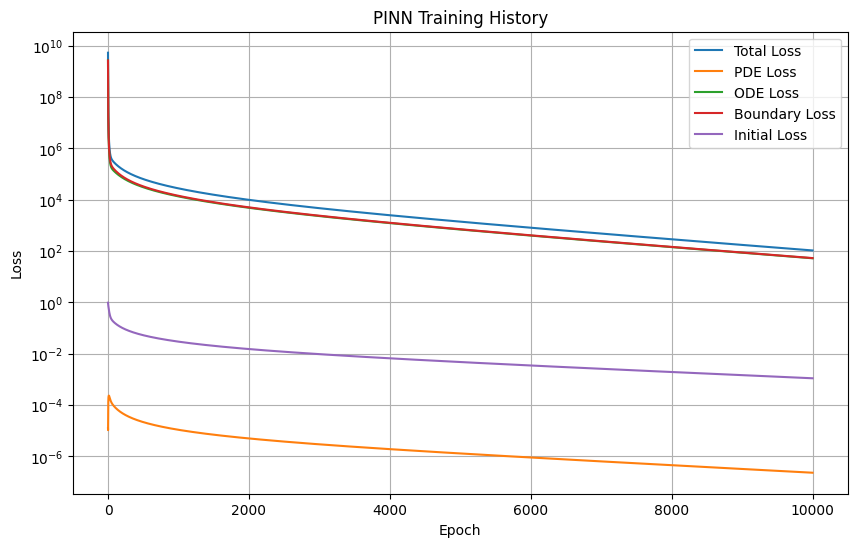

In [120]:
# ==========================================================
# Plot Training History
# ==========================================================

plt.figure(figsize=(10,6))

plt.semilogy(loss_history, label="Total Loss")
plt.semilogy(pde_history, label="PDE Loss")
plt.semilogy(ode_history, label="ODE Loss")
plt.semilogy(bc_history, label="Boundary Loss")
plt.semilogy(ic_history, label="Initial Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training History")

plt.grid(True)

plt.legend()

plt.show()

In [121]:
# ==========================================================
# Prediction
# ==========================================================

def predict(z, t):

    z = tf.convert_to_tensor(z, dtype=tf.float32)
    t = tf.convert_to_tensor(t, dtype=tf.float32)

    inputs = tf.concat([z, t], axis=1)

    prediction = model(inputs)

    c = prediction[:,0:1]

    cb = prediction[:,1:2]

    return c.numpy(), cb.numpy()

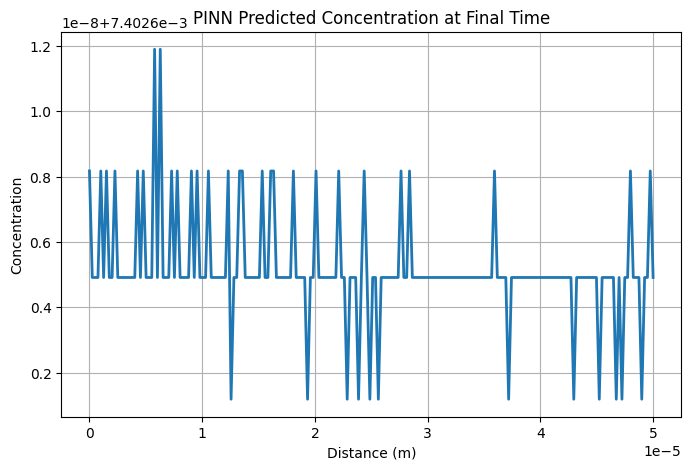

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PINN PERFORMANCE AGAINST NUMERICAL SOLVER
MSE             : 5.527069e-05
MAE             : 7.428187e-03
Relative Error  : 2.171649e+02
Bound Concentration MSE : 9.183245e-05
Bound Concentration MAE : 9.573091e-03


In [122]:
# ==========================================================
# Example Prediction (Visualization)
# ==========================================================

z_test = np.linspace(0, h, 200).reshape(-1, 1)
t_test = np.ones_like(z_test) * tfinal

c_pred, cb_pred = predict(z_test, t_test)

plt.figure(figsize=(8,5))
plt.plot(z_test, c_pred, linewidth=2)

plt.xlabel("Distance (m)")
plt.ylabel("Concentration")
plt.title("PINN Predicted Concentration at Final Time")
plt.grid(True)
plt.show()

# ==========================================================
# Evaluation Using Numerical Solver Results
# ==========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/"

# Load numerical solver data
coordinates = np.load(DATA_PATH + "coordinates.npy")
concentration = np.load(DATA_PATH + "concentration.npy")
binding = np.load(DATA_PATH + "binding.npy")
time_history = np.load(DATA_PATH + "time.npy")

# Extract coordinates
z_eval = coordinates[:, 0:1]
t_eval = coordinates[:, 1:2]

# PINN prediction
c_pred, cb_pred = predict(z_eval, t_eval)

# Performance metrics
mse = mean_squared_error(concentration, c_pred.flatten())
mae = mean_absolute_error(concentration, c_pred.flatten())
relative_error = (
    np.linalg.norm(concentration - c_pred.flatten())
    / np.linalg.norm(concentration)
)

print("\n" + "="*60)
print("PINN PERFORMANCE AGAINST NUMERICAL SOLVER")
print("="*60)
print(f"MSE             : {mse:.6e}")
print(f"MAE             : {mae:.6e}")
print(f"Relative Error  : {relative_error:.6e}")
print("="*60)

mse_cb = mean_squared_error(binding, cb_pred.flatten())
mae_cb = mean_absolute_error(binding, cb_pred.flatten())

print(f"Bound Concentration MSE : {mse_cb:.6e}")
print(f"Bound Concentration MAE : {mae_cb:.6e}")

c_grid min : 0.007402601
c_grid max : 0.019720204
cb_grid min : 0.009518246
cb_grid max : 0.026503481


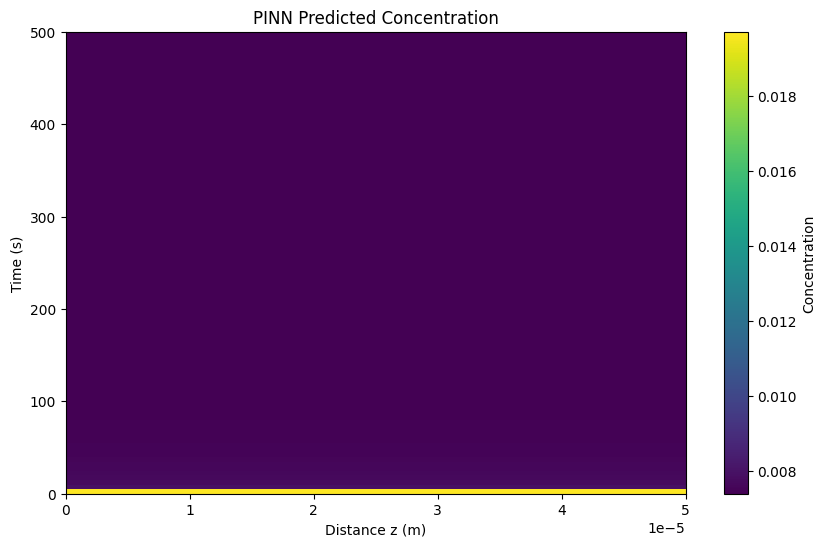

In [123]:
# ==========================================================
# Heatmap of Concentration
# ==========================================================

Nz = 100
Nt = 100

z = np.linspace(0, h, Nz)
t = np.linspace(t0, tfinal, Nt)

Z, T = np.meshgrid(z, t)

z_flat = Z.reshape(-1,1)
t_flat = T.reshape(-1,1)

c_grid, cb_grid = predict(z_flat, t_flat)
print("c_grid min :", np.min(c_grid))
print("c_grid max :", np.max(c_grid))

print("cb_grid min :", np.min(cb_grid))
print("cb_grid max :", np.max(cb_grid))

C = c_grid.reshape(Nt, Nz)

plt.figure(figsize=(10,6))

plt.imshow(
    C,
    extent=[0,h,t0,tfinal],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Concentration')

plt.xlabel("Distance z (m)")
plt.ylabel("Time (s)")
plt.title("PINN Predicted Concentration")

plt.show()

In [124]:
print("Training concentration")
print(np.min(concentration))
print(np.max(concentration))

Training concentration
0.0
4.48e-05


In [135]:
print("Numerical Solver")
print(concentration.min())
print(concentration.max())

print()

print("PINN")
print(c_grid.min())
print(c_grid.max())

Numerical Solver
0.0
4.48e-05

PINN
0.007402601
0.019720204


In [125]:
t = 100

z_plot = np.linspace(0, h, 200).reshape(-1,1)
t_plot = np.ones_like(z_plot) * t

c_pred, _ = predict(z_plot, t_plot)

print(c_pred.min(), c_pred.max())

0.0074329106 0.0074329213


In [126]:
print(np.min(concentration))
print(np.max(concentration))

0.0
4.48e-05


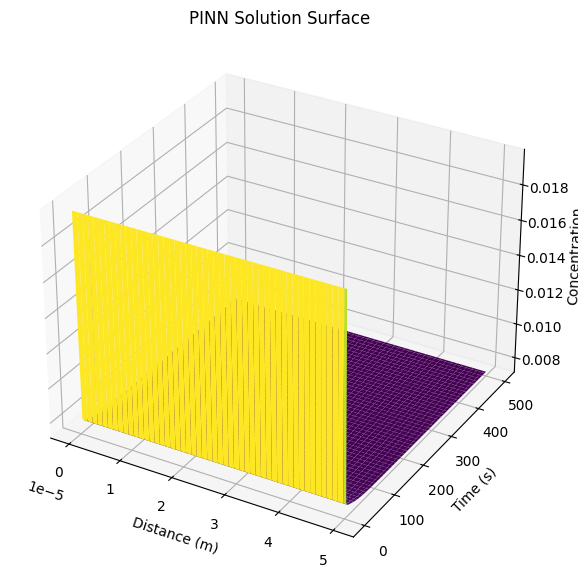

In [127]:
# ==========================================================
# 3D Surface Plot
# ==========================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Z,
    T,
    C,
    cmap='viridis'
)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_zlabel("Concentration")

plt.title("PINN Solution Surface")

plt.show()

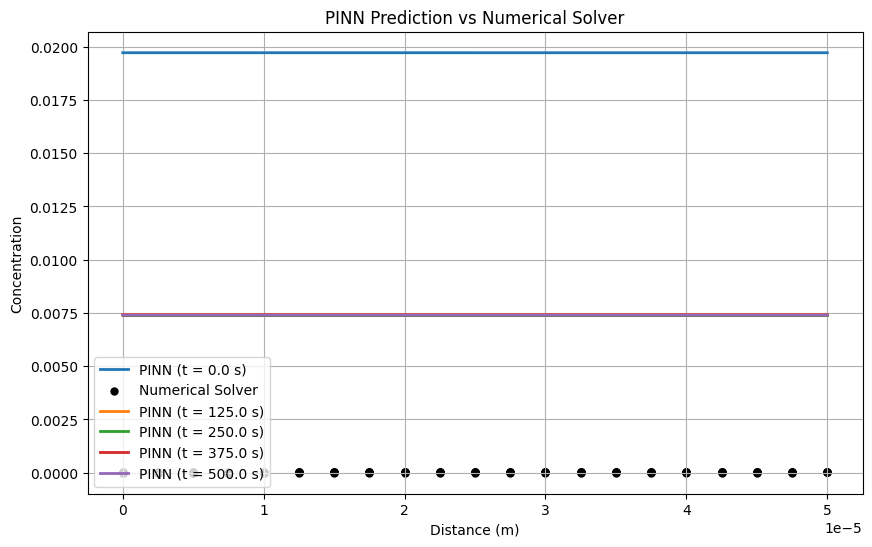

In [128]:
# ==========================================================
# Concentration Profiles (PINN vs Numerical Solver)
# ==========================================================

times = [
    0,
    tfinal * 0.25,
    tfinal * 0.50,
    tfinal * 0.75,
    tfinal
]

plt.figure(figsize=(10,6))

# Available times from the numerical solver
saved_times = np.unique(coordinates[:,1])

for i, tt in enumerate(times):

    # ------------------------------------------------------
    # PINN Prediction
    # ------------------------------------------------------
    z_plot = np.linspace(0, h, 200).reshape(-1,1)
    t_plot = np.ones_like(z_plot) * tt

    c_pred, _ = predict(z_plot, t_plot)

    plt.plot(
        z_plot,
        c_pred,
        linewidth=2,
        label=f"PINN (t = {tt:.1f} s)"
    )

    # ------------------------------------------------------
    # Numerical Solver (closest saved time)
    # ------------------------------------------------------
    closest_time = saved_times[np.argmin(np.abs(saved_times - tt))]
    mask = coordinates[:,1] == closest_time

    plt.scatter(
        coordinates[mask,0],
        concentration[mask],
        color='black',
        marker='o',
        s=25,
        label="Numerical Solver" if i == 0 else None
    )

plt.xlabel("Distance (m)")
plt.ylabel("Concentration")
plt.title("PINN Prediction vs Numerical Solver")
plt.grid(True)
plt.legend()
plt.show()

In [129]:
print(time_history.shape)
print(binding.shape)
print(coordinates.shape)

(20000,)
(420000,)
(420000, 2)


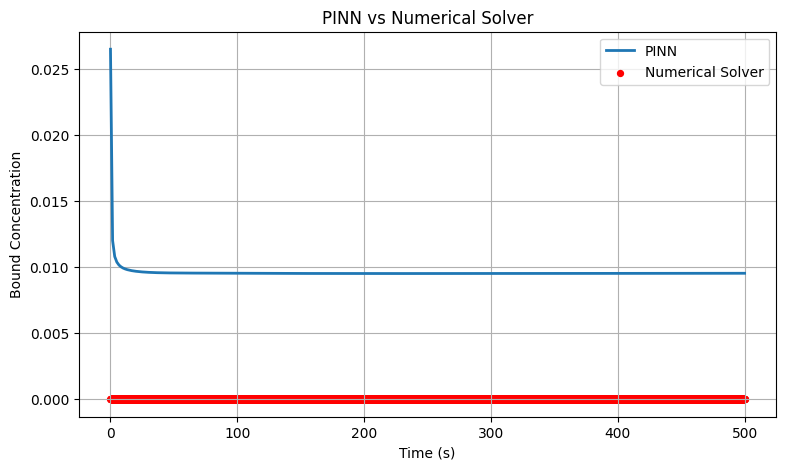

PINN Evaluation
MSE            : 9.341186e-05
MAE            : 9.613841e-03
Relative Error : 4.723802e+05
Training history saved.
Prediction results saved.
      PHYSICS-INFORMED NEURAL NETWORK FINAL REPORT

Model Information
----------------------------------------------------------------------
Architecture        : Physics-Informed Neural Network (PINN)
Training Dataset    : Numerical Solver Output
Hidden Layers       : 8
Neurons / Layer     : 64
Activation          : tanh

Training
----------------------------------------------------------------------
Epochs              : 10000
Learning Rate       : 0.001
Collocation Points  : 10000
Boundary Points     : 2000
Initial Points      : 2000

Performance
----------------------------------------------------------------------
Final Total Loss    : 1.043258e+02
Final PDE Loss      : 2.280738e-07
Final ODE Loss      : 5.171378e+01
MSE                 : 9.341186e-05
MAE                 : 9.613841e-03
Relative Error      : 4.723802e+05

Genera

In [130]:
# ==========================================================
# Bound Concentration (PINN vs Numerical Solver)
# ==========================================================

import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Number of spatial nodes
num_z = len(np.unique(coordinates[:,0]))

# One bound concentration value per time step
binding_plot = binding.reshape(-1, num_z)[:,0]

# PINN prediction at z = 0
t_plot = np.linspace(t0, tfinal, 300).reshape(-1,1)
z_zero = np.zeros_like(t_plot)

_, cb_boundary = predict(z_zero, t_plot)

plt.figure(figsize=(9,5))

# ----------------------------------------------------------
# PINN
# ----------------------------------------------------------
plt.plot(
    t_plot,
    cb_boundary,
    linewidth=2,
    label="PINN"
)

# ----------------------------------------------------------
# Numerical Solver
# ----------------------------------------------------------
plt.scatter(
    time_history,
    binding_plot,
    color="red",
    s=18,
    label="Numerical Solver"
)

plt.xlabel("Time (s)")
plt.ylabel("Bound Concentration")
plt.title("PINN vs Numerical Solver")
plt.grid(True)
plt.legend()
plt.show()

# ==========================================================
# Evaluation Metrics
# ==========================================================

binding_interp = np.interp(
    t_plot.flatten(),
    time_history,
    binding_plot
)

mse = mean_squared_error(
    binding_interp,
    cb_boundary.flatten()
)

mae = mean_absolute_error(
    binding_interp,
    cb_boundary.flatten()
)

eps = 1e-12

relative_error = (
    np.linalg.norm(cb_boundary.flatten()-binding_interp)
    /
    (np.linalg.norm(binding_interp) + eps)
)

print("="*60)
print("PINN Evaluation")
print("="*60)
print(f"MSE            : {mse:.6e}")
print(f"MAE            : {mae:.6e}")
print(f"Relative Error : {relative_error:.6e}")
print("="*60)

# ==========================================================
# Save Training History
# ==========================================================

history = pd.DataFrame({

    "Total Loss": loss_history,
    "PDE Loss": pde_history,
    "ODE Loss": ode_history,
    "Boundary Loss": bc_history,
    "Initial Loss": ic_history

})

history.to_csv(
    "Training_History.csv",
    index=False
)

print("Training history saved.")

# ==========================================================
# Save Prediction Results
# ==========================================================

results = pd.DataFrame({

    "z": z_flat.flatten(),
    "t": t_flat.flatten(),
    "Concentration": c_grid.flatten(),
    "Bound Concentration": cb_grid.flatten()

})

results.to_csv(
    "PINN_Predictions.csv",
    index=False
)

print("Prediction results saved.")

# ==========================================================
# Final Report
# ==========================================================

print("="*70)
print("      PHYSICS-INFORMED NEURAL NETWORK FINAL REPORT")
print("="*70)

print("\nModel Information")
print("-"*70)

print("Architecture        : Physics-Informed Neural Network (PINN)")
print("Training Dataset    : Numerical Solver Output")
print(f"Hidden Layers       : {NUM_HIDDEN}")
print(f"Neurons / Layer     : {NUM_NEURONS}")
print("Activation          : tanh")

print("\nTraining")
print("-"*70)

print(f"Epochs              : {EPOCHS}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Collocation Points  : {N_COLLOCATION}")
print(f"Boundary Points     : {N_BOUNDARY}")
print(f"Initial Points      : {N_INITIAL}")

print("\nPerformance")
print("-"*70)

print(f"Final Total Loss    : {loss_history[-1]:.6e}")
print(f"Final PDE Loss      : {pde_history[-1]:.6e}")
print(f"Final ODE Loss      : {ode_history[-1]:.6e}")
print(f"MSE                 : {mse:.6e}")
print(f"MAE                 : {mae:.6e}")
print(f"Relative Error      : {relative_error:.6e}")

print("\nGenerated Files")
print("-"*70)

print("✓ PINN_Antibody_Model.keras")
print("✓ Training_History.csv")
print("✓ PINN_Predictions.csv")

print("="*70)
print("PHYSICS-INFORMED NEURAL NETWORK COMPLETED SUCCESSFULLY")
print("="*70)

In [131]:
# ==========================================================
# Save Trained Model
# ==========================================================

model.save_weights("PINN_Model.weights.h5")

print("Model saved successfully.")

Model saved successfully.


In [132]:
# ==========================================================
# Load Saved Model
# ==========================================================

# Recreate the model
model = PINN()

# Build the model once
dummy = tf.zeros((1, 2), dtype=tf.float32)
_ = model(dummy)

# Load the weights
model.load_weights("PINN_Model.weights.h5")

print("Weights loaded successfully!")

Weights loaded successfully!


In [133]:
# ==========================================================
# Save Loss History
# ==========================================================

import pandas as pd

history = pd.DataFrame({

    "Total Loss":loss_history,

    "PDE Loss":pde_history,

    "ODE Loss":ode_history,

    "Boundary Loss":bc_history,

    "Initial Loss":ic_history

})

history.to_csv(

    "Training_History.csv",

    index=False

)

print("Training history saved.")

Training history saved.


In [134]:
# ==========================================================
# Save Prediction Results
# ==========================================================

results = pd.DataFrame({

    "z":z_flat.flatten(),

    "t":t_flat.flatten(),

    "Concentration":c_pred.flatten(),

    "Bound Concentration":cb_pred.flatten()

})

results.to_csv(

    "PINN_Predictions.csv",

    index=False

)

print("Prediction results saved.")

ValueError: All arrays must be of the same length

In [ ]:
print("="*50)
print("Physics-Informed Neural Network Completed")
print("="*50)

print(f"Final Total Loss : {loss_history[-1]:.4e}")
print(f"Final PDE Loss   : {pde_history[-1]:.4e}")
print(f"Final ODE Loss   : {ode_history[-1]:.4e}")

print("\nSaved Files")
print("---------------------------")
print("PINN_Antibody_Model.keras")
print("Training_History.csv")
print("PINN_Predictions.csv")

In [ ]:
predictions = model(X_test).numpy()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# =====================================
# Evaluation Metrics
# =====================================

mse = mean_squared_error(y_true.flatten(), predictions.flatten())

mae = mean_absolute_error(y_true.flatten(), predictions.flatten())

relative_error = (
    np.linalg.norm(y_true - predictions)
    / np.linalg.norm(y_true)
)

print(f"MSE            : {mse:.6e}")
print(f"MAE            : {mae:.6e}")
print(f"Relative Error : {relative_error:.6e}")